# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.


In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

Zillow relies on timely, accurate estimates of a property's value to power the products and services that make it money: consumer-facing valuation tools (like the Zestimate), lead generation for real estate agents, and, at the time this dataset was collected, its Zillow Offers home-buying business. The specific column we are predicting, `taxvaluedollarcnt`, is the county assessor's estimate of a property's total assessed value, which is closely related to (but not identical to) market value. The business objective of this project is to build a regression model that predicts this assessed value directly from property characteristics such as size, location, age, and amenities, so that Zillow can generate a value estimate for a property automatically and at scale, rather than depending purely on county assessments (which can be infrequent, inconsistent across counties, and slow to reflect market changes) or expensive manual appraisals. In short, the project turns a labor-intensive, manual valuation problem into an automated, data-driven one that can be applied consistently across millions of properties.


**1.2:**  How will your solution be used?

The model's predictions would feed into several downstream, decision-support workflows rather than being used as a fully autonomous financial decision. Internally, the predicted value could be compared against a property's actual assessed value (or a recent sale price, if available) to flag properties that appear over- or under-assessed, which is useful both for Zillow's own analytics and potentially for consumers appealing their property taxes. The predictions could also be surfaced on consumer-facing property pages as an estimated value, similar to a Zestimate, to help buyers, sellers, and agents gauge a fair price range. A pricing or investment team could use the model as one input (alongside other signals) when deciding which properties to target for offers or marketing campaigns. Finally, since the assignment asks us to present results to a marketing team, the model and its outputs would also be used as a decision-support tool in that presentation, illustrating which property characteristics most strongly drive value and where the model is confident versus uncertain, rather than being deployed as the sole basis for any transaction.

**1.3:**  How should success (or failure) be measured?

On the technical side, success should be measured with standard regression metrics computed on a held-out test set, most likely RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error), since these are interpretable directly in dollars and are the metrics used in the original Zillow Prize competition (which used a related log-error metric). Because `taxvaluedollarcnt` is heavily right-skewed, it may also be informative to look at percentage-based errors (like MAPE) so that a large absolute error on an expensive property isn't weighted the same as a large absolute error on an inexpensive one, and to compare the model against a simple baseline (e.g., predicting the median value, or a simple linear regression on a few features) to make sure the added complexity is actually earning its keep. Just as important is checking that errors are not systematically biased for particular subgroups, for example by county (`fips`), by property type, or by price range, since a model that is accurate on average but consistently under- or over-predicts for certain neighborhoods would be a business failure even with a good overall RMSE. In business terms, success means the predictions are close enough, and unbiased enough, to be trustworthy inputs for the downstream uses described in 1.2; failure would look like large or systematically biased errors that would mislead a homeowner, agent, or internal team relying on the estimate.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Load the dataset into a DataFrame
df = pd.read_csv('zillow_dataset.csv')

# Preview the first few rows to see what the raw data looks like
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
# Structure of the DataFrame: column names, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [5]:
# Number of unique values per column
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [6]:
# Build a single summary table combining dtype, % missing, and # unique values
# for every feature, to make it easier to scan all characteristics at once.
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
})
summary

,dtype,pct_missing,n_unique
parcelid,int64,0.00,77414
airconditioningtypeid,float64,67.78,5
architecturalstyletypeid,float64,99.73,5
basementsqft,float64,99.94,43
bathroomcnt,float64,0.04,22
bedroomcnt,float64,0.04,16
buildingclasstypeid,float64,99.98,2
buildingqualitytypeid,float64,35.82,12
calculatedbathnbr,float64,0.84,21
decktypeid,float64,99.21,1


#### **2.A Discussion:**

Answer the following questions. You may wish to examine Appendix 3 before starting.

**2.A.1:**  Which features are categorical?

Even though most of the "type" columns are stored as floats or ints, they represent codes for categories rather than measurable quantities, so they are categorical. Based on Appendix 1 and the flowchart in Appendix 3, we identified the following as categorical features: `airconditioningtypeid`, `architecturalstyletypeid`, `buildingclasstypeid`, `buildingqualitytypeid` (ordinal), `decktypeid`, `fips`, `heatingorsystemtypeid`, `pooltypeid10`, `pooltypeid2`, `pooltypeid7`, `propertycountylandusecode`, `propertylandusetypeid`, `propertyzoningdesc`, `regionidcity`, `regionidcounty`, `regionidneighborhood`, `regionidzip`, `storytypeid`, and `typeconstructiontypeid`. In addition, `hashottuborspa`, `fireplaceflag`, and `taxdelinquencyflag` are binary/boolean categorical flags stored as object/boolean columns. Geographic identifiers like `rawcensustractandblock` and `censustractandblock` are also more like categorical/identifier codes than continuous measurements, even though they look numeric.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Yes. `parcelid` is a unique identifier assigned to each property; it carries no information about a property's characteristics or value and would only encourage the model to memorize individual rows, so it should be dropped as a predictor. `assessmentyear` takes on exactly one value (2016) for every single row in the dataset, so it has zero variance and cannot possibly help distinguish one property from another. `rawcensustractandblock` and `censustractandblock` both encode nearly the same census tract/block geography and largely duplicate the information already captured by `latitude`, `longitude`, and the `regionid*` columns, so keeping both (or even one, given the other geographic columns) adds redundancy without new business signal. These are conceptually useless regardless of how much data is missing or how many unique values they have; they simply don't describe anything about the property that would plausibly relate to its assessed value.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Yes, several features are missing for the overwhelming majority of properties, which makes it very unlikely that imputing them would add reliable signal. For example, `buildingclasstypeid` is missing for almost 100% of rows, `storytypeid` and `basementsqft` are each missing for close to 100%, and `architecturalstyletypeid` just under 100%, `typeconstructiontypeid` also just under 100%, `fireplaceflag` just less than 100%, `taxdelinquencyflag`/`taxdelinquencyyear` just under 100%, `hashottuborspa` just less than 100%, and `poolsizesum` just less than 100% are all missing for nearly every row. So these are strong candidates for removal in Part 3.B rather than imputation.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Yes, in two different ways. At one extreme, several columns have only 1-2 unique non-null values, meaning they carry almost no discriminating information even where they are present; examples include `storytypeid`, `decktypeid`, `pooltypeid10`, `pooltypeid2`, `poolcnt`, and `fireplaceflag`, all of which take on a single value (e.g., `True` or a single type code) whenever they are not null, essentially functioning as rare flags rather than informative features. At the other extreme, some columns are almost as granular as an identifier: `latitude` and `longitude` have roughly 64,000 and 62,000 unique values respectively (nearly one per property), and `rawcensustractandblock`/`censustractandblock` have around 39,000 unique values each. These aren't "useless" in the same way as `parcelid`, since geography clearly matters for property value, but at this level of granularity they behave more like identifiers than like features a model can generalize from directly; they would likely need to be grouped, binned, or used differently (e.g., as coordinates or joined to a coarser region) rather than used as raw categorical codes.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features):
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

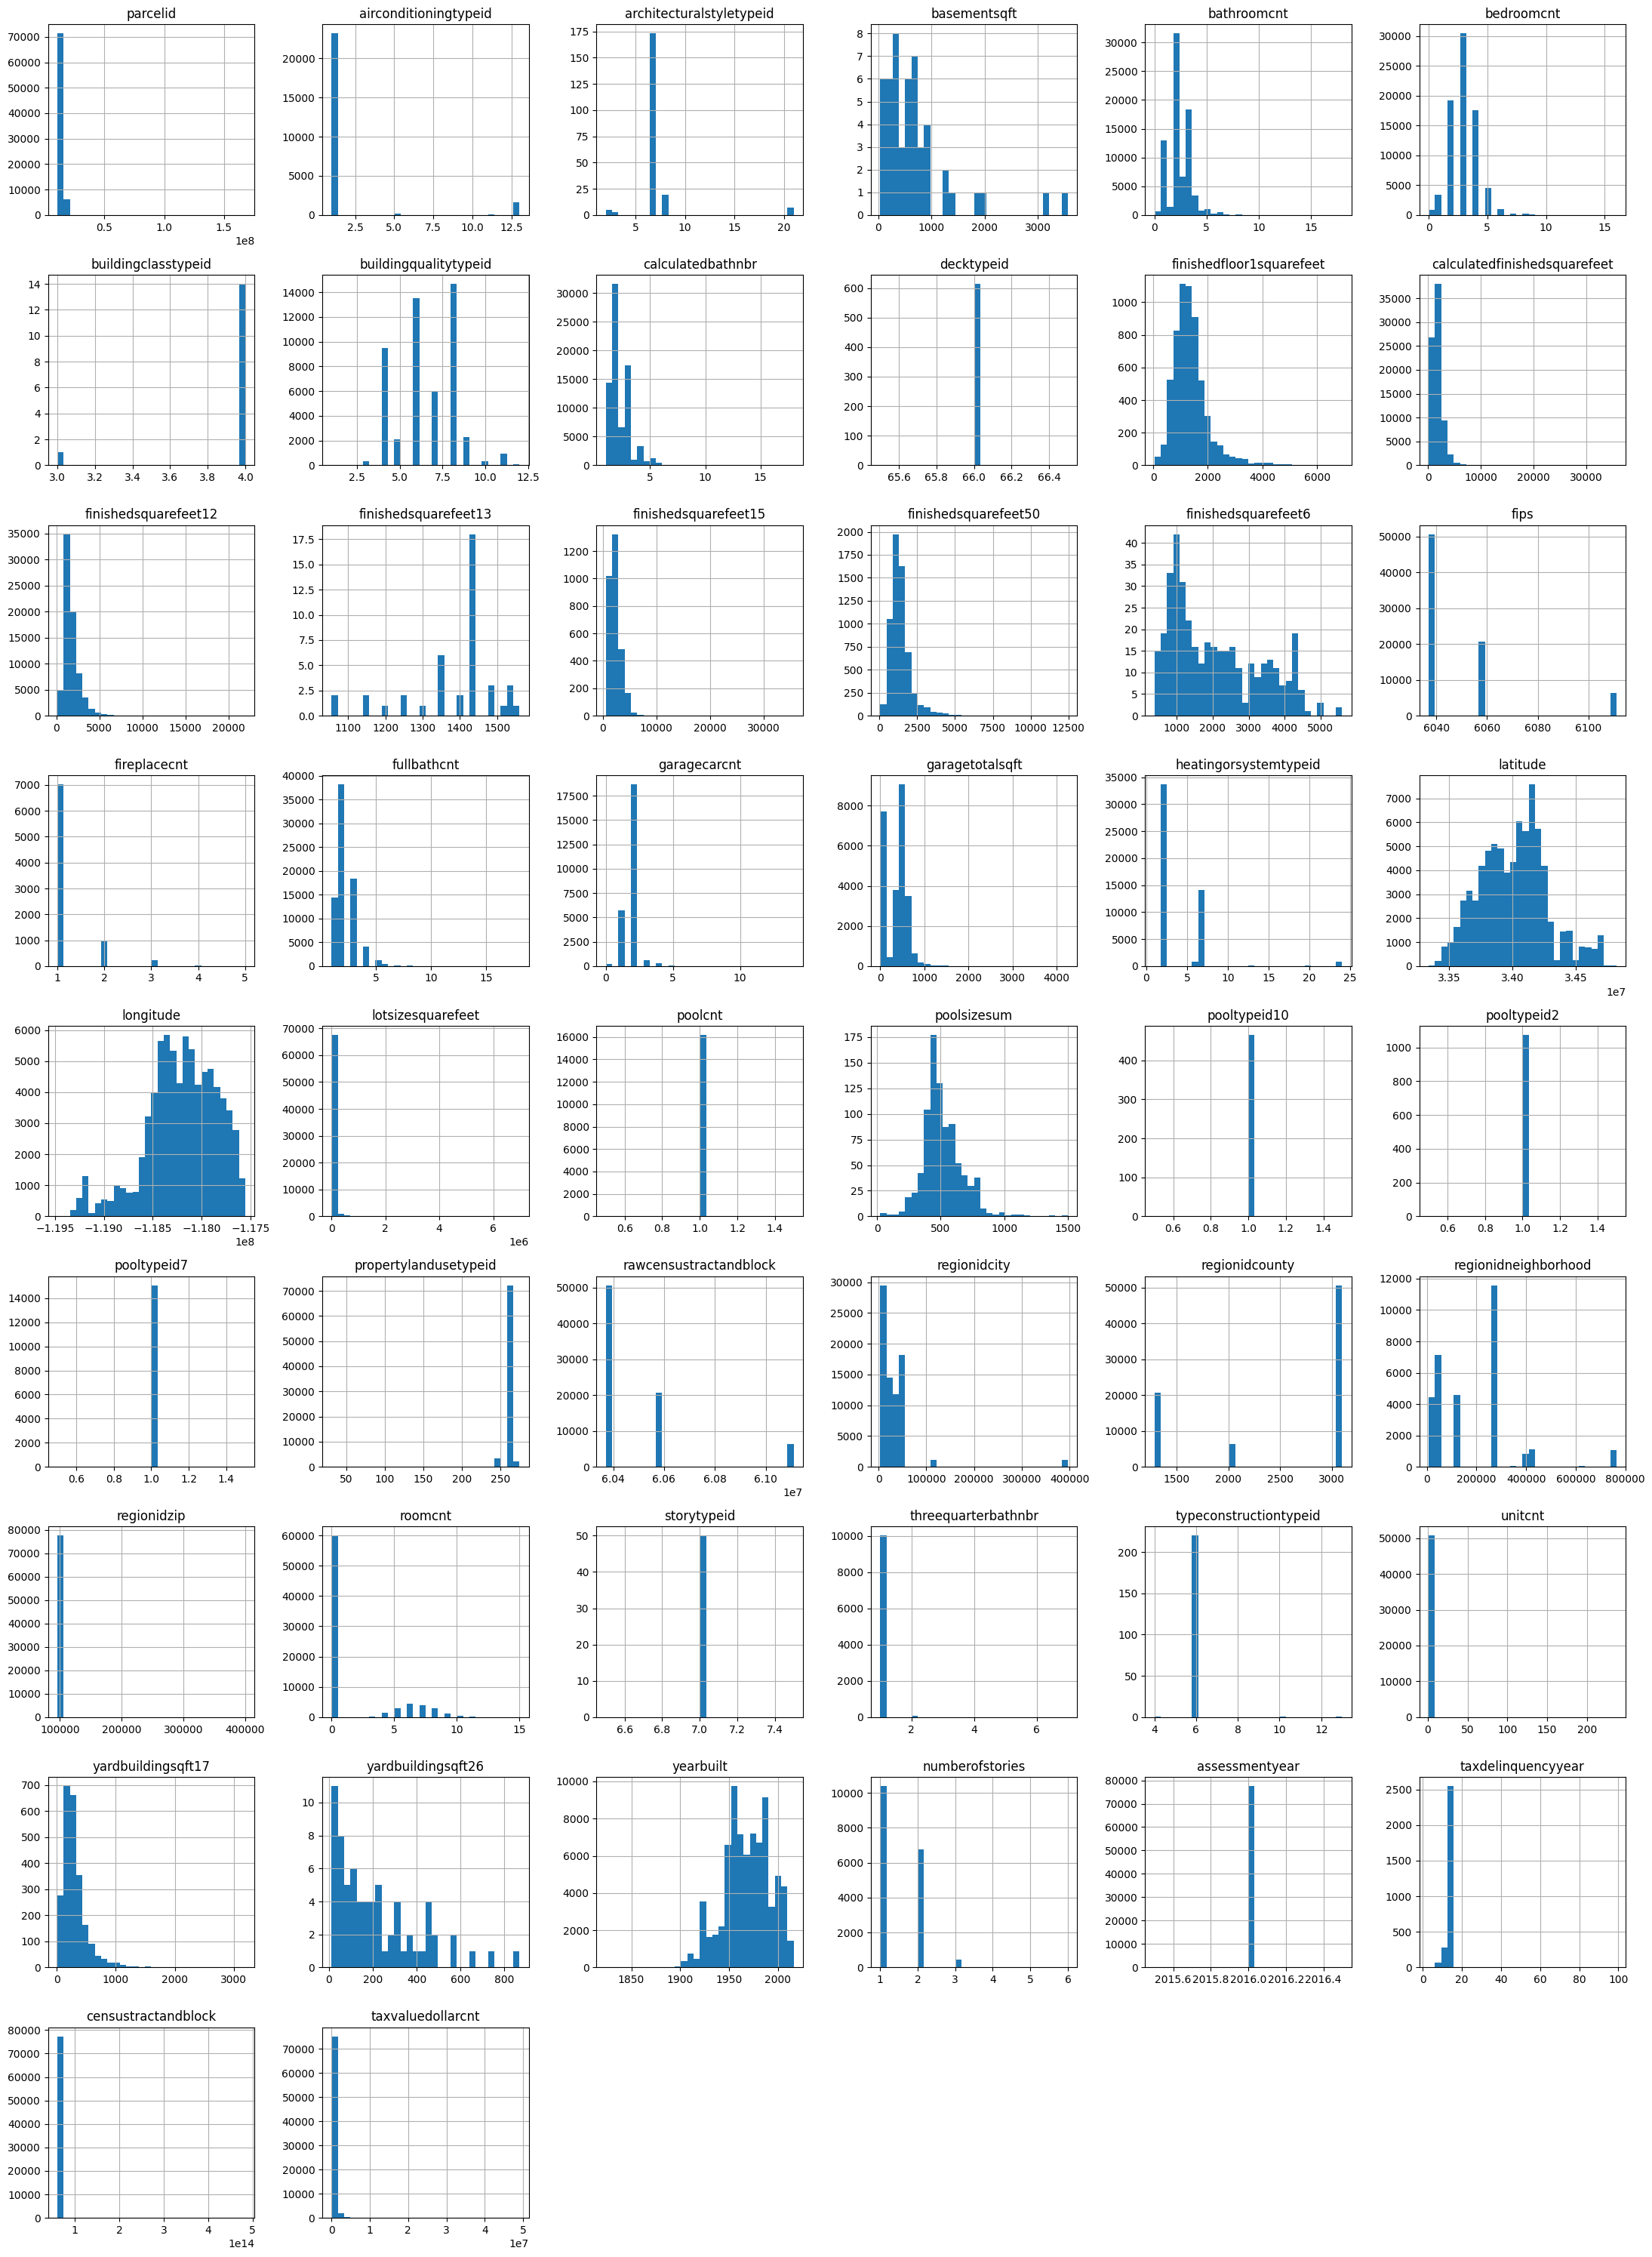

In [7]:
# Overview of every numeric feature's distribution using df.hist().
df.hist(figsize=(22, 30), layout=(-1, 6), bins=30)
plt.tight_layout()
plt.show()

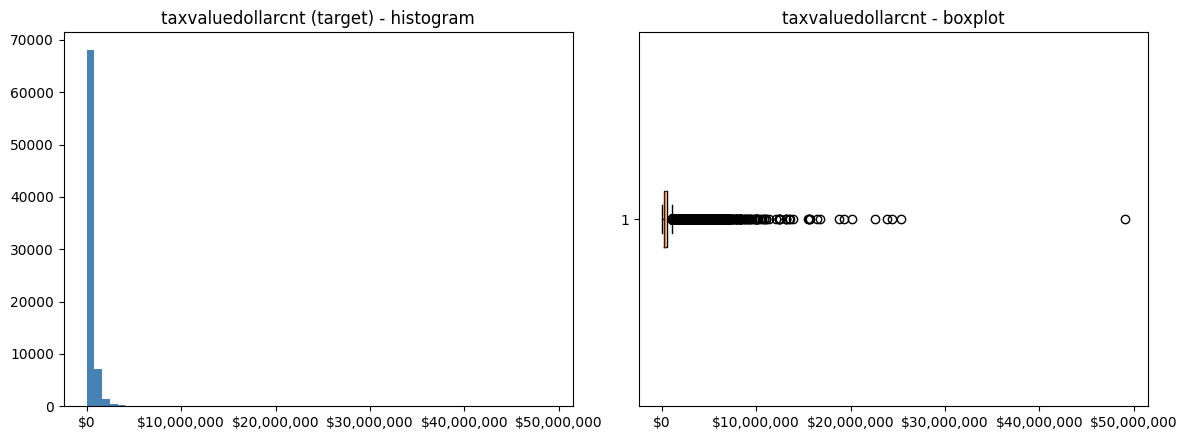

In [8]:
#Feature 1:  taxvaluedollarcnt (target)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=60, color='steelblue')
axes[0].set_title('taxvaluedollarcnt (target) - histogram')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), vert=False)
axes[1].set_title('taxvaluedollarcnt - boxplot')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

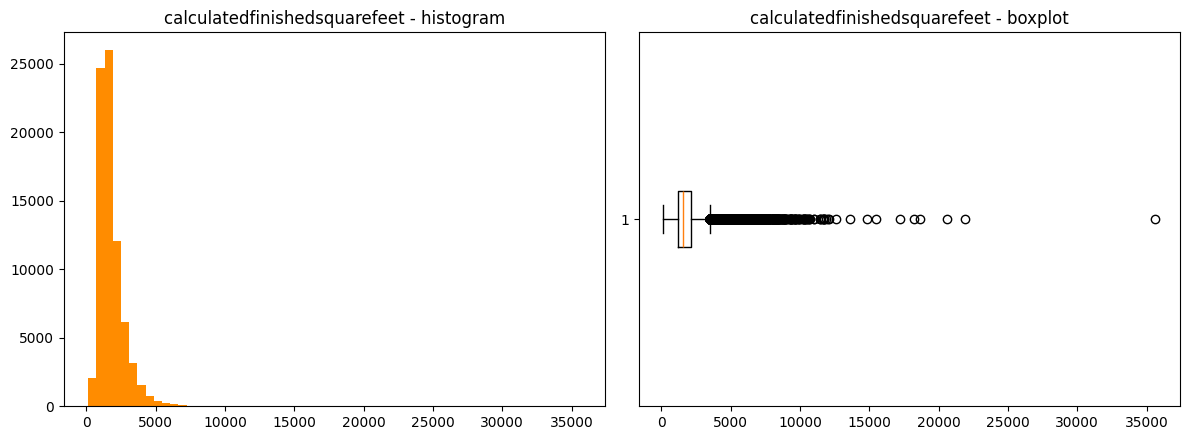

In [9]:
# Feature 2: calculatedfinishedsquarefeet
# Histogram + boxplot for this numerical measure of home size.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=60, color='darkorange')
axes[0].set_title('calculatedfinishedsquarefeet - histogram')

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=False)
axes[1].set_title('calculatedfinishedsquarefeet - boxplot')

plt.tight_layout()
plt.show()

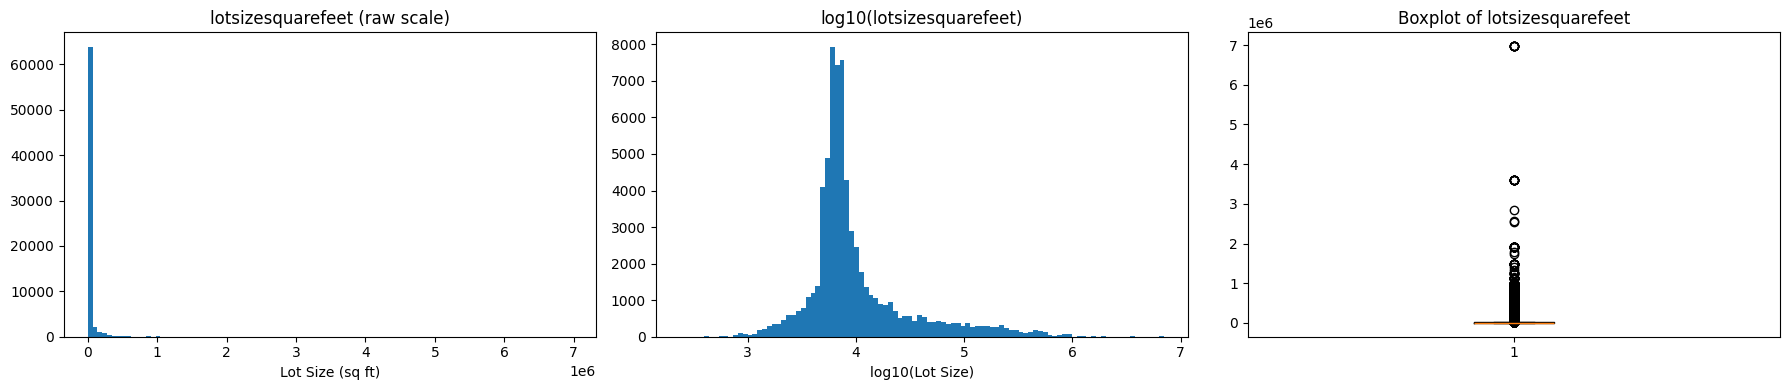

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64

In [10]:
# Feature 3: lotsizesquarefeet
# This feature turns out to be extremely skewed, so we look at it on both
# a normal and a log scale to see the shape more clearly, plus a boxplot.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['lotsizesquarefeet'].dropna(), bins=100)
axes[0].set_title('lotsizesquarefeet (raw scale)')
axes[0].set_xlabel('Lot Size (sq ft)')

axes[1].hist(np.log10(df['lotsizesquarefeet'].dropna()), bins=100)
axes[1].set_title('log10(lotsizesquarefeet)')
axes[1].set_xlabel('log10(Lot Size)')

axes[2].boxplot(df['lotsizesquarefeet'].dropna(), orientation='vertical')
axes[2].set_title('Boxplot of lotsizesquarefeet')

plt.tight_layout()
plt.show()

df['lotsizesquarefeet'].describe()

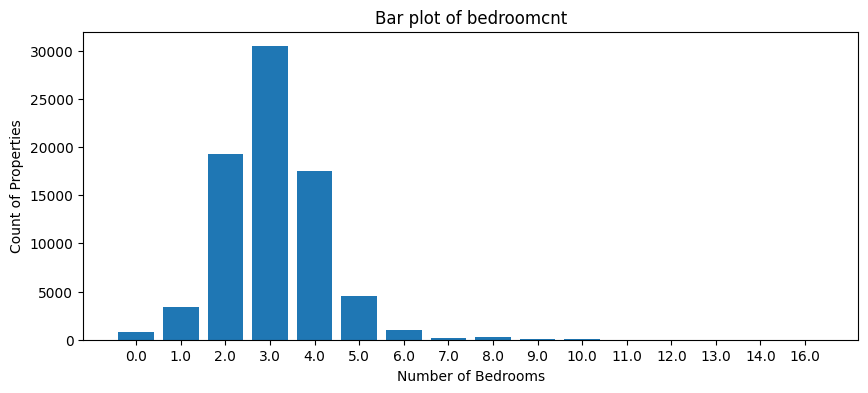

count    77579.000000
mean         3.053223
std          1.140480
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         16.000000
Name: bedroomcnt, dtype: float64

In [11]:
# Feature 4: bedroomcnt
# This is a discrete count that behaves almost like a categorical feature,
# so a bar plot of value counts is more informative than a plain histogram.
counts = df['bedroomcnt'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title('Bar plot of bedroomcnt')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count of Properties')
plt.show()

df['bedroomcnt'].describe()

#### **2.B Discussion:**

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

**taxvaluedollarcnt (target).** Heavily right-skewed (median ~$359K, max ~$49M), with a small number of very high-value outliers stretching the distribution. Missing values are negligible.

**calculatedfinishedsquarefeet.** Also right-skewed but less extreme, with most homes in the 1,200–2,100 sq ft range and a few unusually large outliers. Selected because home size is an intuitive predictor of value, and it shows a similar skew pattern to the target.

**lotsizesquarefeet.** The most skewed feature by far, with a max lot size (~7M sq ft) that repeats identically across rows — a strong sign of a data quality issue rather than a real lot size. About 10.7% missing.

**bedroomcnt.** A discrete count feature, roughly bell-shaped and centered at 3 bedrooms. Mostly well-behaved, but includes some questionable values (837 properties with 0 bedrooms).

**Conclusion.** Three of the four features (the target, `calculatedfinishedsquarefeet`, and especially `lotsizesquarefeet`) are strongly right-skewed with high-value outliers, so all three are good candidates for a log transformation before modeling, and `lotsizesquarefeet` in particular needs a closer look at its repeated extreme values to decide whether they should be treated as outliers, corrected, or dropped. `bedroomcnt` is comparatively well-behaved, but its 0-bedroom entries deserve a domain-informed decision (are they legitimate, or should they be treated as missing/imputed?). All four have the majority of the data, so for these particular features the main preprocessing task in Part 3 is less about imputation and more about transformation and outlier handling.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [12]:
import pandas as pd

zillow = pd.read_csv("zillow_dataset.csv")

In [13]:
housing_drop = zillow.copy()

cols_to_drop = [
    "parcelid",                  # This is a unique ID and doesn't describe the property
    "assessmentyear",            # Has little predictive value 
    "censustractandblock",       # Geographic identifier and not numeric features 
    "rawcensustractandblock",    # Geographic identifier and not numeric features 
    "propertycountylandusecode", # Administrative land use code
    "propertyzoningdesc"         # Zoning code with many unique values
]

housing_drop = housing_drop.drop(columns=cols_to_drop)

housing_drop.head()

,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,...,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
0,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,...,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,NaN,NaN,1023282.0
1,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,...,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,NaN,NaN,464000.0
2,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,NaN,NaN,564778.0
3,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,...,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,NaN,NaN,145143.0
4,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,...,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,NaN,NaN,119407.0


#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

***For this part, I removed parcelid, assessmentyear, censustractandblock, raw censustractandblock, propertycountylandusecode, and propertyzoningdesc because these colunms does not help predict a property's assessed tax value. 

I removed parcelid because it is only a unique identificiation number for each property. Since every property has a different ID, its unlikely to provide useful information for making predictions. 

I removed assessmentyear because almost every property was assessed in the same year. Since there is a litte variation, it is unlikely to improve the model.

I removed censustractandblock and rawcensustractandblock because these are geographic identification codes. Although, location can affect property values, these codes themselves do not provide meaningful information unless they are transformed into more useful location features. 

Finally, I removed propertycountylandusecode and propertyzoningdesc because these are administractive codes with many different values. These would require additional processing before they could be useful in a regreession model, so I decided to leave them out. Also, without additional processing, I don't think they would contribute much to predicting the tax value.

My decisions are based on what each feature represents, whether it provides useful information for predicting the target and not because of missing values. 


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [14]:
missing_percent = (housing_drop.isnull().sum() / len(housing_drop)) * 100   # Calculate the percentage of missing values in each column

missing_percent.sort_values(ascending=False)    # Display columns with missing values

buildingclasstypeid             99.980673
finishedsquarefeet13            99.945885
basementsqft                    99.935578
storytypeid                     99.935578
yardbuildingsqft26              99.909809
fireplaceflag                   99.778388
architecturalstyletypeid        99.733292
typeconstructiontypeid          99.712677
finishedsquarefeet6             99.502661
pooltypeid10                    99.400874
decktypeid                      99.208895
poolsizesum                     98.880342
pooltypeid2                     98.616211
hashottuborspa                  98.017085
yardbuildingsqft17              96.916754
taxdelinquencyflag              96.263513
taxdelinquencyyear              96.263513
finishedsquarefeet15            96.099880
finishedsquarefeet50            92.221664
finishedfloor1squarefeet        92.221664
fireplacecnt                    89.320088
threequarterbathnbr             86.978985
pooltypeid7                     80.571554
poolcnt                         79

Based on the results, I dropped the columns with more than 50% missing values because it doesn't have much data to be useful for predicting the property's assessed tax value:


In [15]:
cols_to_drop = missing_percent[missing_percent > 50].index      # Drop columns with more than 50% missing values

housing_clean = housing_drop.drop(columns=cols_to_drop)

housing_clean.info()        # Check the remaining columns

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   77579 non-null  float64
 1   bedroomcnt                    77579 non-null  float64
 2   buildingqualitytypeid         49809 non-null  float64
 3   calculatedbathnbr             76963 non-null  float64
 4   calculatedfinishedsquarefeet  77378 non-null  float64
 5   finishedsquarefeet12          73923 non-null  float64
 6   fips                          77579 non-null  float64
 7   fullbathcnt                   76963 non-null  float64
 8   heatingorsystemtypeid         49571 non-null  float64
 9   latitude                      77579 non-null  float64
 10  longitude                     77579 non-null  float64
 11  lotsizesquarefeet             69321 non-null  float64
 12  propertylandusetypeid         77579 non-null  float64
 13  regionidcity

#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

I chose this threshold because the features with more than 50% missing data may not provide enough of information for the model to learn from. Keeping these faeatures could also require too much imputation, which may add inaccurate assumptions and reduce the quality of the analysis. Zillow dataset has many features available, I believe it was better to remove columns with a large amount of missing data and focus on features that had more complete information.

Before removing the columns, I also considered whether the remaining non-null values could still be useful. A feature with missing values is not always useless, especially if the available values provide important information about the target variable. However, after reviewing the columns with high missing percentages, I decided that the amount of available data was too limited to make the feature reliable. Removing these features helped reduce unnecessary information and made the dataset cleaner for the modeling process. 

In [16]:
missing_percent = (housing_drop.isnull().sum() / len(housing_drop)) * 100   # Calculate the percentage of missing values in each column

missing_percent.sort_values(ascending=False)    # Display columns with missing values

buildingclasstypeid             99.980673
finishedsquarefeet13            99.945885
basementsqft                    99.935578
storytypeid                     99.935578
yardbuildingsqft26              99.909809
fireplaceflag                   99.778388
architecturalstyletypeid        99.733292
typeconstructiontypeid          99.712677
finishedsquarefeet6             99.502661
pooltypeid10                    99.400874
decktypeid                      99.208895
poolsizesum                     98.880342
pooltypeid2                     98.616211
hashottuborspa                  98.017085
yardbuildingsqft17              96.916754
taxdelinquencyflag              96.263513
taxdelinquencyyear              96.263513
finishedsquarefeet15            96.099880
finishedsquarefeet50            92.221664
finishedfloor1squarefeet        92.221664
fireplacecnt                    89.320088
threequarterbathnbr             86.978985
pooltypeid7                     80.571554
poolcnt                         79

In [17]:
cols_to_drop = missing_percent[missing_percent > 50].index      # Drop columns with more than 50% missing values

housing_clean = housing_drop.drop(columns=cols_to_drop)

housing_clean.info()        # Check the remaining columns

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   77579 non-null  float64
 1   bedroomcnt                    77579 non-null  float64
 2   buildingqualitytypeid         49809 non-null  float64
 3   calculatedbathnbr             76963 non-null  float64
 4   calculatedfinishedsquarefeet  77378 non-null  float64
 5   finishedsquarefeet12          73923 non-null  float64
 6   fips                          77579 non-null  float64
 7   fullbathcnt                   76963 non-null  float64
 8   heatingorsystemtypeid         49571 non-null  float64
 9   latitude                      77579 non-null  float64
 10  longitude                     77579 non-null  float64
 11  lotsizesquarefeet             69321 non-null  float64
 12  propertylandusetypeid         77579 non-null  float64
 13  regionidcity

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [18]:
df_clean = df.copy()

target = "taxvaluedollarcnt"

df_clean = df_clean.dropna(subset=[target])

feature_cols = [col for col in df_clean.columns if col != target]

missing_pct = df_clean[feature_cols].isnull().mean(axis=1)

threshold = 0.60    # I justified the threshold at 60% to remove the least informative data samples and keeping most of the observations

df_clean = df_clean.loc[missing_pct <= threshold].copy()

print("Dataset shape after removing problematic samples:")
print(df_clean.shape)

Dataset shape after removing problematic samples:
(76826, 55)


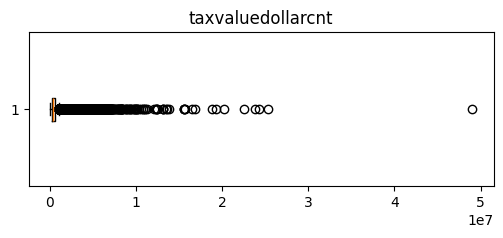

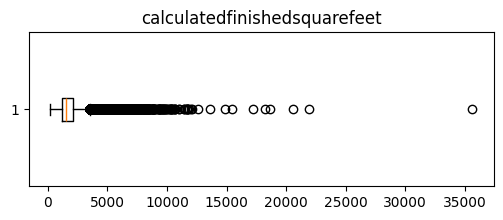

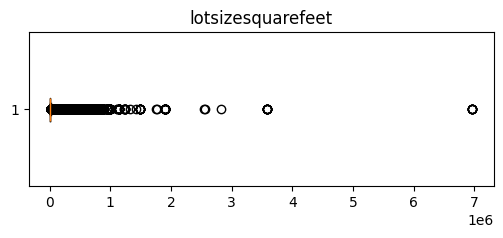

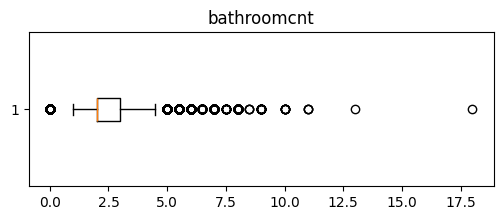

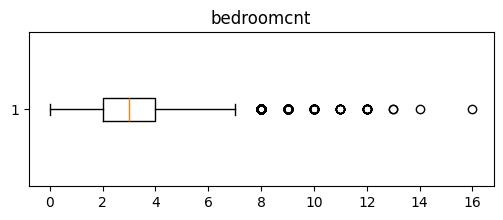

In [19]:
numeric_cols = df_clean.select_dtypes(include=["number"]).columns       # Investigate potential outliers (Do Not Remove Them)

columns_to_plot = [
    "taxvaluedollarcnt",
    "calculatedfinishedsquarefeet",
    "lotsizesquarefeet",
    "bathroomcnt",
    "bedroomcnt"
]

for col in columns_to_plot:
    if col in df_clean.columns:
        plt.figure(figsize=(6,2))
        plt.boxplot(df_clean[col].dropna(), vert=False)
        plt.title(col)
        plt.show()

#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

***First, I removed samples that had any missing values for the target variable, for example: taxvaluedollarcnt, because supervised learning models require a known target value during training. I also removed samples with more than 60% missing feature values. This threshold was chosen because the dataset contains a large amount of missing data, and removing only the most incomplete records helps improve data quality while maintaining most of the available samples for model training. 

Second, to investigate potential outliers, I created boxplots for several important numerical variables, for example: taxvaluedollarcnt, calculatedfinishedsquarefeet, lotsizesquarefeet, bathroomcnt, and bedroomcnt. The boxplots showed several observations that were much higher or lower than the majority of the data, indicating potential outliers. However, I chose not to remove these observations because they may represent real properties, for example: luxury homes or large lots rather than data entry errors. 

Third, removing all outliers can help improve the model by reducing the impact of unusually large or small values that can affect the results. However, some of these extreme values may represent real properties rather than errors, so removing them could cause the model to lose useful information. Instead of removing them now, it makes more sense to test their impact in Milestone 2 by comparing the model's performance with and without the outliers.  

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage").

No discussion necessary.

In [20]:
X = housing_clean.drop(columns=["taxvaluedollarcnt"])       # This separates the features and target
y = housing_clean["taxvaluedollarcnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (62090, 19)
X_test: (15523, 19)
y_train: (62090,)
y_test: (15523,)


### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [21]:
numeric_cols = X_train.select_dtypes(include=["number"]).columns

median_imputer = SimpleImputer(strategy="median")

X_train[numeric_cols] = median_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = median_imputer.transform(X_test[numeric_cols])

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


***After cleaning the dataset, I used median imputation to fill in the remaining missing values because all of the features left in the training data were numeric. I chose the median because housing data can contain outliers, and the median is less affected by extreme values than the mean.

While working on this process, I initially expected to use a separate imputation method for categorical features as well. However, after checking the data, I found that there were no categorical columns reamining because they had already been removed during the earlier cleaning process. Only the numeric features were left, median imputation was the only method needed. 

Therefore, to avoid data leakage, I fit the imputer using only the training data and then applied it to both the training and test sets. After imputing the missing values, I verified that there were no missing values remaining in the training and test datasets. 

#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

***The overall imputation strategy I used involved applying different methods depending on whether the feature was numerical or categorical. For example, numerical features I used is the median imputation to fill in missing values. I chose the median instead of the mean because many real world datasets can contain extreme values that can affect the average. The median provides a better representation of the typical value and helps reduce the impact of outliers when filling in the missing data. 

As for categorical features, I used the mode imputation, which replaces missing values with the category that appears most often in that feature. This method made the most sense because categorical variables represent groups or labels, so using a numerical calculation like an average would not be meaningful. 

Lastly, I decided to use different imputation methods for numerical and categorical features because they contain different types of information. Numerical features can be summarized using statistics like the median, while categorical features are better handled by using the most common category. Using separate methods allowed me to preserve the meaning of each feature and create a cleaner dataset for the modeling process. 

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical features:", categorical_features)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_features)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Training shape after encoding:", X_train_encoded.shape)
print("Testing shape after encoding:", X_test_encoded.shape)

Categorical features: []
Training shape after encoding: (62090, 19)
Testing shape after encoding: (15523, 19)


***After completing the previous data cleaning and preprocessing steps, I checked the dataset for any remaining categorical features that would require encoding. The output showed me that there were no categorical features remaining. I also reviewed the feature descritptions from [Appendix 1 and Appendix 3] to make sure that variables were not incorrectly classified as numerical simply because they were stored as integer values. Also, reviewing the remaining features, the variables left in the dataset were treated as numerical features rather then categorical variables. 

Finally, there were no remaining categorical features, neither One-Hot Encoding or Ordinal Encoding was needed. The dataset maintained the same number of features after the encoding step, with the training set containing 62,090 rows and 19 features and the testing set containing 15,523 rows and 19 features. This confirmed that the data was already prepared for model training without requiring additional categorical transformations. 

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

***After completing the earlier preprocessing steps, I checked the dataset for any remaining categorical features that needed to be encoded. The results showed that there were no categorical features remaining in the dataset. Because of this, there were no features that required classification as either nominal or ordinal, and no One-Hot Encoding or Ordinal Encoding was necessary. 

Before making this decision, I reviewed the feature descriptions in Appendix 1 and Appendix 3 to make sure that features were not being treated as numerical only because they were stored as integer values. Some features in the original dataset, such as property identifier variables for example: propertylandusetypeid, may appear numeric but actually represent different categorical because the numbers act as labels or codes and do not have a meaningful mathematical relationship. If any of these identifier based categorical features remained after preprocessing, I would have used One-Hot Encoding because the categories do not have a natural order.

Also, I reviewed the remaining features in the cleaned dataset and determined that the variables left were numerical measurements rather than categorical variables. Therefore, the dataset did not require any additional encoding and was ready for model training with the existing 19 features. 

## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

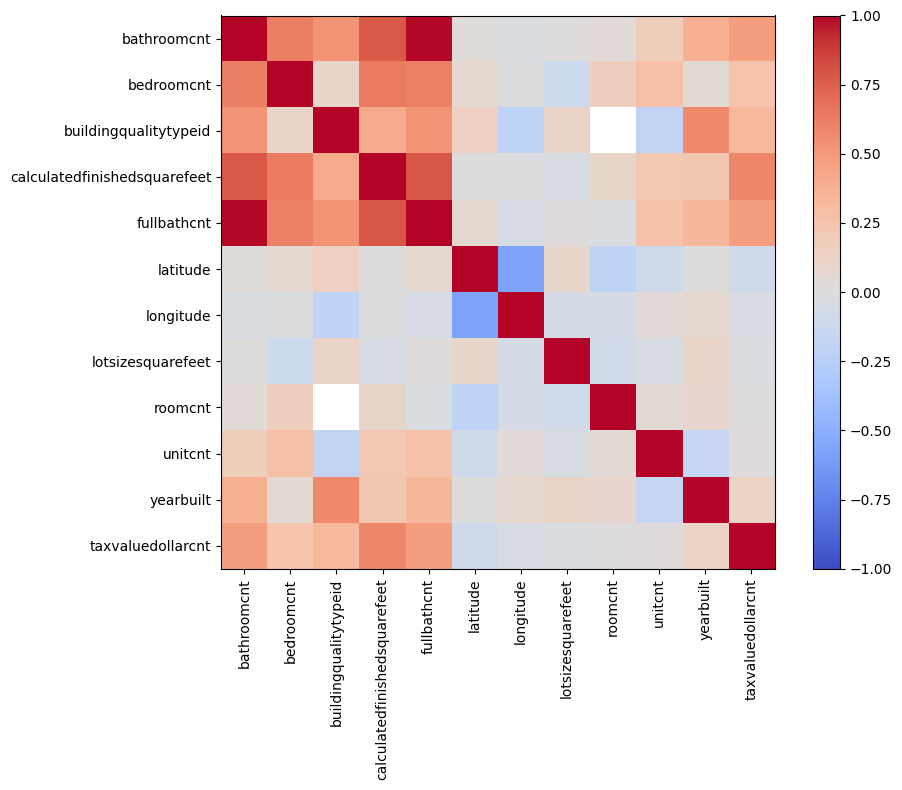

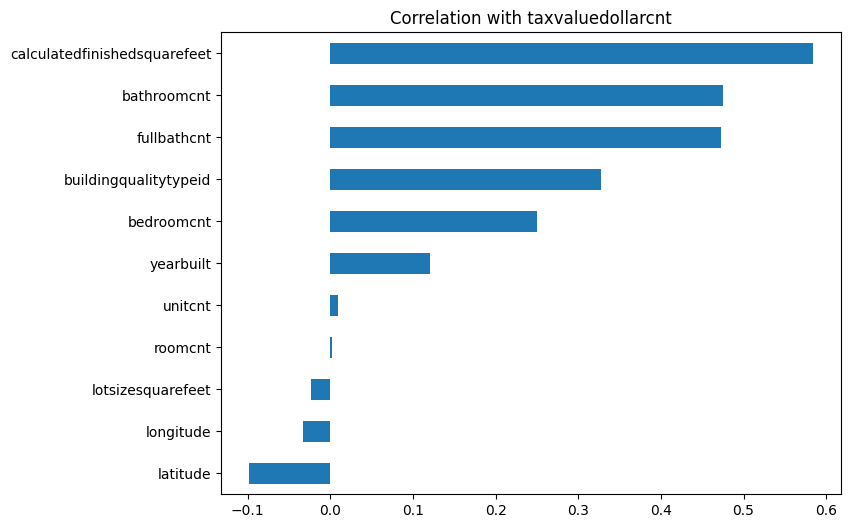

,feature,F_stat
3,calculatedfinishedsquarefeet,39781.444149
0,bathroomcnt,22330.980535
4,fullbathcnt,21734.503889
1,bedroomcnt,5116.816476
2,buildingqualitytypeid,4674.627460
10,yearbuilt,1133.140219
5,latitude,744.595526
6,longitude,85.702713
7,lotsizesquarefeet,32.551654
9,unitcnt,1.186700


In [23]:

numeric_cols = ['bathroomcnt','bedroomcnt','buildingqualitytypeid','calculatedfinishedsquarefeet',
                 'fullbathcnt','latitude','longitude','lotsizesquarefeet','roomcnt','unitcnt',
                 'yearbuilt','taxvaluedollarcnt']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Bar chart isolating correlation with the target
target_corr = corr['taxvaluedollarcnt'].drop('taxvaluedollarcnt').sort_values()
target_corr.plot(kind='barh', figsize=(8,6))
plt.title("Correlation with taxvaluedollarcnt")
plt.show()

# F-statistics as a second, complementary importance signal
from sklearn.feature_selection import f_regression
X_num = df_clean[numeric_cols].drop(columns=['taxvaluedollarcnt']).fillna(df_clean[numeric_cols].median())
f_stats, p_vals = f_regression(X_num, df_clean['taxvaluedollarcnt'])
pd.DataFrame({'feature': X_num.columns, 'F_stat': f_stats}).sort_values('F_stat', ascending=False)

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

**Answers**

The strongest predictors of the target are the following features:

    1. calculatedfinishedsquarefeet (r=0.58
    2. fullbathcnt (r=0.47)
    3. bathroomcnt (r=0.47)
    4. buildingqualitytypeid (r=0.33)
    5. bedroomcnt (r=0.25)
    These five features all track some dimension of  size or "how much house you're getting." 

The pairs of features that appear to be highly correlated are:

    1. bathroomcnt & fullbathcnt (r=0.985, near-duplicate)
    2. calculatedfinishedsquarefeet & fullbathcnt (r=0.79)
    3. calculatedfinishedsquarefeet & bathroomcnt (r=0.77)
    4. bathroomcnt & bedroomcnt (r=0.63)
    These four pairs all cluster around the same underlying concept of house size.
    
The correlation matrix & the F-statistics measurements agreed closely on both ends of the ranking for features: calculatedfinishedsquarefeet, bathroomcnt, and fullbathcnt as the top three features. Both measurements also agreed on the weakest features: roomcnt. and unitcnt. Because the correlation matrix and F-statistics methods measure "importance" through different mathematical apporaches, their agreements provide the confidence that the rankings reflects a real pattern in the data. 



### Part 4.B: Investigate Feature Relationships

In this part, you will explore relationships between pairs of features to better understand the structure of the dataset and identify opportunities for future feature engineering.

In the next cell(s):

- Select three interesting pairs of features to investigate. Choose pairs that you think may have meaningful relationships based on your earlier exploratory analysis.
- Visualize each pair using an appropriate plot, such as a scatter plot, pairplot, box plot, or another suitable visualization.
- Describe the relationship you observe. Consider whether it appears to be linear, nonlinear, weak, strong, or whether little relationship is evident.
- Do not modify the dataset based on these analyses. Any feature engineering or preprocessing decisions will be evaluated experimentally in Milestone 2.

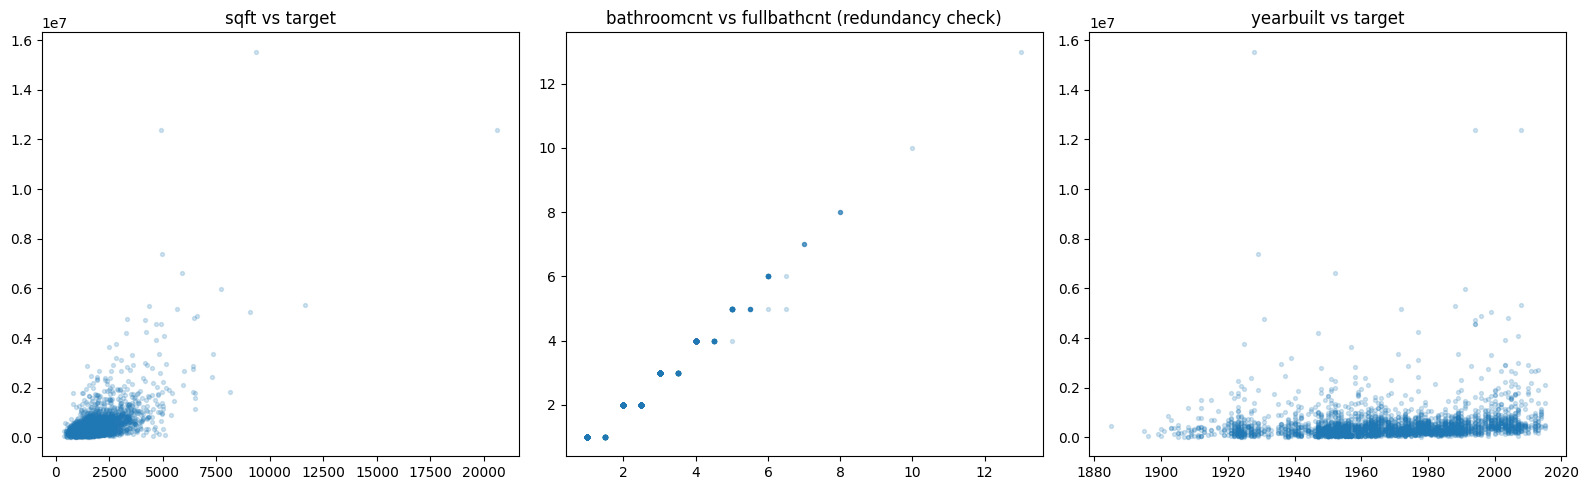

In [24]:

sample = df_clean.sample(3000, random_state=42)  # subsample for a readable scatter

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].scatter(sample['calculatedfinishedsquarefeet'], sample['taxvaluedollarcnt'], alpha=0.2, s=8)
axes[0].set_title('sqft vs target')

axes[1].scatter(sample['bathroomcnt'], sample['fullbathcnt'], alpha=0.2, s=8)
axes[1].set_title('bathroomcnt vs fullbathcnt (redundancy check)')

axes[2].scatter(sample['yearbuilt'], sample['taxvaluedollarcnt'], alpha=0.2, s=8)
axes[2].set_title('yearbuilt vs target')
plt.tight_layout()
plt.show()

In [25]:
# Correlation for each pair, computed on the FULL cleaned dataset (df_clean),
# not the 3,000-row 'sample' — sample is only used for a readable scatter plot,
# the r values themselves should come from all the data

r_sqft_target = df_clean['calculatedfinishedsquarefeet'].corr(df_clean['taxvaluedollarcnt'])
r_bath_fullbath = df_clean['bathroomcnt'].corr(df_clean['fullbathcnt'])
r_year_target = df_clean['yearbuilt'].corr(df_clean['taxvaluedollarcnt'])

print(f"calculatedfinishedsquarefeet vs taxvaluedollarcnt: r = {r_sqft_target:.3f}")
print(f"bathroomcnt vs fullbathcnt:                        r = {r_bath_fullbath:.3f}")
print(f"yearbuilt vs taxvaluedollarcnt:                    r = {r_year_target:.3f}")

calculatedfinishedsquarefeet vs taxvaluedollarcnt: r = 0.584
bathroomcnt vs fullbathcnt:                        r = 0.984
yearbuilt vs taxvaluedollarcnt:                    r = 0.121


#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

**Answers**

1. calculatedfinishedsquarefeet & taxvaluedollarcnt (r=0.58)

    The relationship is positive and roughly linear at low-to-mid square footage, but the spread widens noticeably as square footage increases, forming a fan/cone shape rather than a tight line. This confirms square footage as the strongest individual predictor found in 4.A, though the widening spread at the high end shows that size alone doesn't fully determine value for larger homes.

2. bathroomcnt & fullbathcnt (r=0.985)

    The relationship is strongly linear, with points sitting almost exactly on the identity line. This is the tightest pairing identified in 4.A, and the scatter confirms these two columns are nearly duplicates — fullbathcnt is essentially bathroomcnt with half-baths excluded, rather than two genuinely distinct measurements.

3. yearbuilt & taxvaluedollarcnt (r=0.12)

    The relationship appears weak and scattered, with no clear linear trend visible — points are spread broadly across the value range at almost every build year. This matches the low correlation coefficient from 4.A, but the lack of an obvious pattern doesn't necessarily mean year built is unrelated to value; it may indicate the relationship is non-linear (e.g., value varying by era rather than increasing steadily with age) rather than genuinely absent.

    This was chosen, despite its weak linear correlation because weak does not mean negligble, and it would be a good practice to perform a visual check. A scatterplot may reveal a pattern that the Pearson's r would miss. 

## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

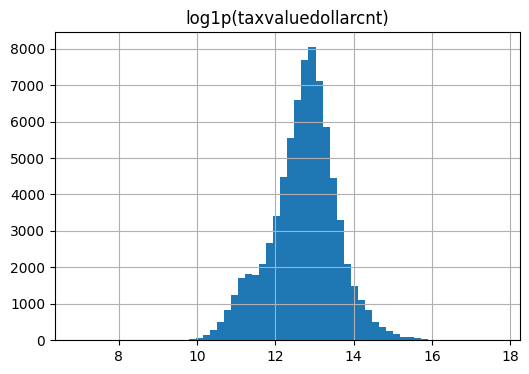

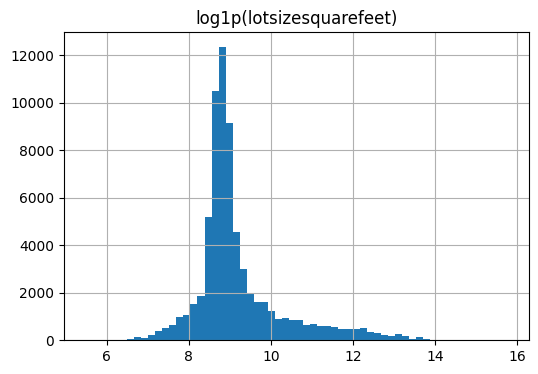

In [32]:
# Log transformations for heavily right-skewed variables

# Target
plt.figure(figsize=(6,4))
np.log1p(df_clean["taxvaluedollarcnt"]).hist(bins=60)
plt.title("log1p(taxvaluedollarcnt)")
plt.show()

# Predictor
plt.figure(figsize=(6,4))
np.log1p(df_clean["lotsizesquarefeet"].dropna()).hist(bins=60)
plt.title("log1p(lotsizesquarefeet)")
plt.show()

In [27]:
#drop/combine the redundant (highly correlated features) bathroom features identified in 4.A/4.B
print(df_clean[['bathroomcnt','fullbathcnt']].corr())


             bathroomcnt  fullbathcnt
bathroomcnt     1.000000     0.984455
fullbathcnt     0.984455     1.000000


In [29]:
#Outlier removal

target = df_clean['taxvaluedollarcnt']
q1, q3 = target.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
trimmed = target[(target >= lo) & (target <= hi)]

print(f"Full: n={len(target)}, skew={target.skew():.2f}, std=${target.std():,.0f}")
print(f"Trimmed: n={len(trimmed)}, skew={trimmed.skew():.2f}, std=${trimmed.std():,.0f}")

Full: n=76826, skew=14.63, std=$651,380
Trimmed: n=71722, skew=0.79, std=$236,888


In [ ]:
#Combining or aggregating features

total_rooms = df_clean['bedroomcnt'] + df_clean['bathroomcnt']
home_age = 2016 - df_clean['yearbuilt']

print("corr(total_rooms, target) =", total_rooms.corr(df_clean['taxvaluedollarcnt']))
print("corr(home_age, target)    =", home_age.corr(df_clean['taxvaluedollarcnt']))



corr(total_rooms, target) = 0.39375217087182846
corr(home_age, target)    = -0.1205906117180608


#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

===  Idea 1: Log Transformation  ===

Features affected: taxvaluedollarcnt and lotsizesquarefeet

Why it may improve the model: The target variable and lot size were both heavily right-skewed during the exploratory analysis. After applying a log1p() transformation, the distributions became much more symmetric, reducing the influence of extreme values. This may help regression models better capture the relationship between these variables and improve prediction accuracy.

How I would evaluate it in Milestone 2: I would train one model using the original variables and another using the log-transformed variables, then compare performance using MAE and RMSE on the validation or test set.


===  Idea 2: Combine or Remove Highly Correlated Features  ===

Features affected: bathroomcnt and fullbathcnt

Why it may improve the model: The correlation analysis showed these two features have a correlation of approximately 0.98, indicating they contain nearly the same information. Keeping both may introduce unnecessary redundancy without improving predictive performance.

How I would evaluate it in Milestone 2: keeping both features,removing one of them,combining them into a single bathroom-related feature,and determine which produces the lowest prediction error.


=== Idea 3: Investigate Outlier Treatment  ===

Features affected: taxvaluedollarcnt, calculatedfinishedsquarefeet and lotsizesquarefeet

Why it may improve the model: These variables contained several extreme observations identified in the histograms and boxplots. While some may represent legitimate luxury properties, others could have a disproportionate influence on the model.

How I would evaluate it in Milestone 2: I would compare models trained with the original data against models that trim or winsorize extreme values and determine whether outlier handling improves prediction accuracy.

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.


1. Log Transformation

Idea prioritized: I would prioritize applying a log transformation to taxvaluedollarcnt and lotsizesquarefeet.

Why I believe it is the most promising: During the exploratory analysis, both variables showed strong right-skewed distributions with a small number of extremely large values. After applying a log1p() transformation, the distributions became much more symmetric, suggesting that the transformation could help the model learn the relationship between these variables more effectively while reducing the influence of extreme values.

Evidence from my exploratory analysis: The histograms in Parts 2 and 5 showed that both variables contained long right tails. The log transformed histograms demonstrated a much more balanced distribution, making log transformation the strongest feature engineering opportunity identified during the exploratory analysis.


2. Remove or Combine Highly Correlated Features

Idea prioritized: I would prioritize evaluating whether bathroomcnt and fullbathcnt should be combined or whether one of them should be removed.

Why I believe it is the most promising: These two variables appear to measure nearly the same characteristic of a property. Using both may introduce unnecessary redundancy without providing much additional predictive information. Reducing redundant features could simplify the model while maintaining similar predictive performance.

Evidence from my exploratory analysis: The correlation analysis showed a correlation of approximately 0.98 between bathroomcnt and fullbathcnt, and the scatter plot confirmed an almost perfect linear relationship. This suggests the two variables contain very similar information, making them strong candidates for feature reduction or combination.


Overall Priority

I selected these two ideas because they are supported by multiple parts of my exploratory analysis. The log transformation directly addressed the strong skewness observed in the distributions, while the correlation analysis clearly identified redundant information between the bathroom related features. Although outlier treatment is another potential improvement, I chose not to prioritize it because many of the extreme observations may represent legitimate high-value properties rather than data errors. I would therefore evaluate outlier handling after testing the first two ideas in Milestone 2.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

![Screenshot 2026-06-28 at 9.25.25 AM.png](attachment:87ba406d-4f6b-4e03-825a-17f4941bb5ac.png)